# 🍱 Food Image Classifier — InceptionV3 Only
### Two-Phase Transfer Learning: Freeze → Fine-Tune

---
**Phase 1 — Train Top Layers Only (base frozen, 20 epochs)**  
The InceptionV3 backbone is locked. Only the custom Dense head is trained.  
This is fast and prevents overwriting the pretrained ImageNet features early on.

**Phase 2 — Fine-Tune Top Layers of Base (20 epochs)**  
We unfreeze the last N layers of InceptionV3 and retrain with a tiny LR.  
The model now adapts its deep features to food images — accuracy typically jumps.

**Why fine-tuning improves performance:**  
ImageNet features are generic (edges, textures, shapes). Fine-tuning nudges the deeper layers to learn *food-specific* features (sauces, crumbs, grain patterns) that Phase 1 cannot reach.

---

## Cell 1 — Imports

In [1]:
import os, json, shutil, zipfile, warnings
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.19.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


## Cell 3 — Config  ← EDIT PATHS HERE

In [3]:
import gdown

FILE_ID = "1HDfl9onT-WSNAPz9_FVu9wfTimJhcDZf"

print("Downloading UECFOOD100 dataset...")
gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", "UECFOOD100.zip", quiet=False)

print("Extracting...")
with zipfile.ZipFile("UECFOOD100.zip", 'r') as zf:
    zf.extractall('/content/')

print("✅ Dataset ready!")

Downloading...
From (original): https://drive.google.com/uc?id=1HDfl9onT-WSNAPz9_FVu9wfTimJhcDZf
From (redirected): https://drive.google.com/uc?id=1HDfl9onT-WSNAPz9_FVu9wfTimJhcDZf&confirm=t&uuid=1239f567-e93b-4427-b445-3c603dae36af
To: /content/UECFOOD100.zip
100%|██████████| 992M/992M [00:05<00:00, 190MB/s]


Extracting...
✅ Dataset ready!


In [16]:
EXTRACT_DIR   = '/content/UECFOOD100'
TRAIN_DIR     = '/content/food40/train'
VAL_DIR       = '/content/food40/val'
SAVE_DIR      = '/content/drive/MyDrive/FoodAI'

IMG_SIZE      = 299       # InceptionV3 native size
BATCH_SIZE    = 32
NUM_CLASSES   = 40
PHASE1_EPOCHS = 25        # more epochs to stabilize top layers
PHASE2_EPOCHS = 10      # fine-tune phase
FINE_TUNE_AT  = 249       # unfreeze last ~50 layers of InceptionV3 (total=311)

os.makedirs(SAVE_DIR, exist_ok=True)
print("Config ready. Output will be saved to:", SAVE_DIR)

Config ready. Output will be saved to: /content/drive/MyDrive/FoodAI


## Cell 4 — Unzip Dataset

In [5]:
if not os.path.exists(EXTRACT_DIR):
    print("Unzipping dataset (may take 2-5 minutes)...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('/content/')
    print("Done! Unzipped to:", EXTRACT_DIR)
else:
    print("Dataset already unzipped — skipping.")

Dataset already unzipped — skipping.


## Cell 5 — Find Dataset Root & Select Classes

In [6]:
def find_class_root(base):
    """Walk the extracted folder tree to find where the
    numbered class directories (1, 2, 3 ...) actually live."""
    for root, dirs, _ in os.walk(base):
        numeric = [d for d in dirs if d.isdigit()]
        if len(numeric) >= 10:
            return root
    return base

DATASET_ROOT = find_class_root(EXTRACT_DIR)
print("Dataset root found at:", DATASET_ROOT)

# Sort class folder names by their integer value, pick first 40
all_numeric      = sorted([d for d in os.listdir(DATASET_ROOT) if d.isdigit()], key=int)
selected_folders = all_numeric[:NUM_CLASSES]
print(f"Selected {len(selected_folders)} class folders: {selected_folders}")

Dataset root found at: /content/UECFOOD100
Selected 40 class folders: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40']


## Cell 6 — Load Category Names

In [7]:
category_txt   = os.path.join(EXTRACT_DIR, 'category.txt')
folder_to_name = {}

if os.path.exists(category_txt):
    with open(category_txt, encoding='utf-8', errors='ignore') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2 and parts[0].isdigit():
                # join multi-word names with underscore
                folder_to_name[parts[0]] = '_'.join(parts[1:])
    print(f"Loaded {len(folder_to_name)} category names.")
else:
    print("category.txt not found — will use folder numbers as class names.")

class_names = [folder_to_name.get(f, f'food_{f}') for f in selected_folders]
print("\nClass list:")
for i, (fld, name) in enumerate(zip(selected_folders, class_names)):
    print(f"  [{i:02d}] folder {fld:>3} → {name}")

Loaded 100 category names.

Class list:
  [00] folder   1 → rice
  [01] folder   2 → eels_on_rice
  [02] folder   3 → pilaf
  [03] folder   4 → chicken-'n'-egg_on_rice
  [04] folder   5 → pork_cutlet_on_rice
  [05] folder   6 → beef_curry
  [06] folder   7 → sushi
  [07] folder   8 → chicken_rice
  [08] folder   9 → fried_rice
  [09] folder  10 → tempura_bowl
  [10] folder  11 → bibimbap
  [11] folder  12 → toast
  [12] folder  13 → croissant
  [13] folder  14 → roll_bread
  [14] folder  15 → raisin_bread
  [15] folder  16 → chip_butty
  [16] folder  17 → hamburger
  [17] folder  18 → pizza
  [18] folder  19 → sandwiches
  [19] folder  20 → udon_noodle
  [20] folder  21 → tempura_udon
  [21] folder  22 → soba_noodle
  [22] folder  23 → ramen_noodle
  [23] folder  24 → beef_noodle
  [24] folder  25 → tensin_noodle
  [25] folder  26 → fried_noodle
  [26] folder  27 → spaghetti
  [27] folder  28 → Japanese-style_pancake
  [28] folder  29 → takoyaki
  [29] folder  30 → gratin
  [30] folder

## Cell 7 — Build Train / Val Split

In [8]:
if not os.path.exists(TRAIN_DIR):
    print("Building train/val folders...")
    os.makedirs(TRAIN_DIR)
    os.makedirs(VAL_DIR)

    for folder, name in zip(selected_folders, class_names):
        src = os.path.join(DATASET_ROOT, folder)
        if not os.path.isdir(src):
            print(f"  WARNING: {src} not found — skipping")
            continue

        # UECFOOD100 mixes images with .txt annotation files — keep only images
        imgs = [f for f in os.listdir(src)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        train_imgs, val_imgs = train_test_split(imgs, test_size=0.2, random_state=42)

        for split, split_list in [('train', train_imgs), ('val', val_imgs)]:
            dest = os.path.join('/content/food40', split, name)
            os.makedirs(dest, exist_ok=True)
            for img in split_list:
                shutil.copy2(os.path.join(src, img), os.path.join(dest, img))

        print(f"  {name}: {len(train_imgs)} train | {len(val_imgs)} val")

    print("Split complete!")
else:
    print("Train/val folders already exist — skipping copy.")

# Use folder names from train directory as the definitive class list
final_classes = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES   = len(final_classes)
print(f"\nFinal class count: {NUM_CLASSES}")

Building train/val folders...
  rice: 496 train | 124 val
  eels_on_rice: 104 train | 26 val
  pilaf: 92 train | 23 val
  chicken-'n'-egg_on_rice: 96 train | 25 val
  pork_cutlet_on_rice: 120 train | 30 val
  beef_curry: 196 train | 50 val
  sushi: 122 train | 31 val
  chicken_rice: 80 train | 20 val
  fried_rice: 135 train | 34 val
  tempura_bowl: 108 train | 28 val
  bibimbap: 89 train | 23 val
  toast: 174 train | 44 val
  croissant: 96 train | 24 val
  roll_bread: 85 train | 22 val
  raisin_bread: 80 train | 21 val
  chip_butty: 118 train | 30 val
  hamburger: 186 train | 47 val
  pizza: 107 train | 27 val
  sandwiches: 130 train | 33 val
  udon_noodle: 121 train | 31 val
  tempura_udon: 84 train | 22 val
  soba_noodle: 130 train | 33 val
  ramen_noodle: 282 train | 71 val
  beef_noodle: 111 train | 28 val
  tensin_noodle: 89 train | 23 val
  fried_noodle: 104 train | 27 val
  spaghetti: 120 train | 31 val
  Japanese-style_pancake: 109 train | 28 val
  takoyaki: 107 train | 27 val


## Cell 8 — Data Generators
> **Note:** `target_size=(299, 299)` — InceptionV3's native resolution.

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,        # normalize pixels to [0, 1]
    rotation_range=30,      # randomly rotate up to 30°
    zoom_range=0.25,        # randomly zoom in/out up to 25%
    width_shift_range=0.2,  # shift image left/right
    height_shift_range=0.2, # shift image up/down
    shear_range=0.2,        # apply shear transformation
    horizontal_flip=True,   # randomly mirror image
    fill_mode='nearest'     # fill empty pixels after transform
)

# Validation generator: only normalize, no augmentation
val_datagen = ImageDataGenerator(rescale=1.0/255)

train_flow = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_flow = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # keep order for evaluation
)

print(f"Training samples   : {train_flow.samples}")
print(f"Validation samples : {val_flow.samples}")
print(f"Classes            : {train_flow.num_classes}")

Found 5353 images belonging to 40 classes.
Found 1359 images belonging to 40 classes.
Training samples   : 5353
Validation samples : 1359
Classes            : 40


## Cell 9 — Calorie Dictionary

In [10]:
_BASE_CALORIES = {
    "rice":130, "eels_on_rice":165, "pilaf":180,
    "chicken_and_egg_on_rice":175, "pork_cutlet_on_rice":248,
    "beef_curry":150, "sushi":143, "chicken_rice":160,
    "fried_rice":185, "tempura":290, "bibimbap":120,
    "toast":265, "croissant":406, "roll_bread":280,
    "ramen_noodle":136, "takoyaki":165, "gratin":136,
    "sauteed_vegetables":70, "croquette":243, "hamburger":295,
    "pizza":266, "sandwiches":233, "udon_noodle":96,
    "pocky":476, "green_salad":15, "almond_jelly":95,
    "XO_sauce":156, "fried_egg":196, "minced_meat_fritters":250,
    "cream_puff":262, "waffles":291, "french_fries":312,
    "spring_rolls":185, "mixed_rice":140, "gnocchi":130,
    "macaroni_salad":165, "clam_chowder":80, "steak":271,
    "BBQ_beef":260, "cookie":480,
}

## Cell 10 — Map Calories to Classes

In [11]:
# Map calorie values to the actual class folder names we are using
calorie_dict = {}
for cls in final_classes:
    if cls in _BASE_CALORIES:
        calorie_dict[cls] = _BASE_CALORIES[cls]
    else:
        # fuzzy partial-name match
        matched = False
        for key, cal in _BASE_CALORIES.items():
            if key.lower() in cls.lower() or cls.lower() in key.lower():
                calorie_dict[cls] = cal
                matched = True
                break
        if not matched:
            calorie_dict[cls] = 200  # sensible default

print("Calorie dictionary built:")
for k, v in calorie_dict.items():
    print(f"  {k}: {v} kcal/100g")

Calorie dictionary built:
  Japanese-style_pancake: 200 kcal/100g
  beef_curry: 150 kcal/100g
  beef_noodle: 200 kcal/100g
  bibimbap: 120 kcal/100g
  chicken-'n'-egg_on_rice: 130 kcal/100g
  chicken_rice: 160 kcal/100g
  chip_butty: 200 kcal/100g
  croissant: 406 kcal/100g
  croquette: 243 kcal/100g
  eels_on_rice: 165 kcal/100g
  fried_noodle: 200 kcal/100g
  fried_rice: 185 kcal/100g
  gratin: 136 kcal/100g
  grilled_eggplant: 200 kcal/100g
  hamburger: 295 kcal/100g
  miso_soup: 200 kcal/100g
  oden: 200 kcal/100g
  omelet: 200 kcal/100g
  pilaf: 180 kcal/100g
  pizza: 266 kcal/100g
  pork_cutlet_on_rice: 248 kcal/100g
  potage: 200 kcal/100g
  raisin_bread: 200 kcal/100g
  ramen_noodle: 136 kcal/100g
  rice: 130 kcal/100g
  roll_bread: 280 kcal/100g
  sandwiches: 233 kcal/100g
  sausage: 200 kcal/100g
  sauteed_spinach: 200 kcal/100g
  sauteed_vegetables: 70 kcal/100g
  soba_noodle: 200 kcal/100g
  spaghetti: 200 kcal/100g
  sushi: 143 kcal/100g
  takoyaki: 165 kcal/100g
  tempura

## Cell 11 — Callbacks

In [12]:
def make_callbacks(save_path):
    """Standard callbacks used for every training run."""
    return [
        # Stop if val_accuracy doesn't improve for 8 consecutive epochs
        EarlyStopping(monitor='val_accuracy', patience=8,
                      restore_best_weights=True, verbose=1),
        # Save model only when val_accuracy improves
        ModelCheckpoint(save_path, monitor='val_accuracy',
                        save_best_only=True, verbose=1),
        # Reduce LR by 70% when val_loss is stuck for 4 epochs
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=4, min_lr=1e-7, verbose=1),
    ]

## Cell 12 — Build InceptionV3 Model


In [ ]:
def build_inceptionv3(num_classes, img_size):
    base = InceptionV3(weights='imagenet', include_top=False,
                       input_shape=(img_size, img_size, 3))
    base.trainable = False   # freeze for Phase 1

    inp = keras.Input(shape=(img_size, img_size, 3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(512, activation='relu')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inp, out, name='InceptionV3_Food'), base

iv3_model, iv3_base = build_inceptionv3(NUM_CLASSES, IMG_SIZE)
print("InceptionV3 ready. Params:", f"{iv3_model.count_params():,}")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
InceptionV3 ready. Params: 22,995,528


## Cell 13 — Phase 1 Training (Base Frozen, 20 Epochs)
Only the Dense head is trained. The InceptionV3 backbone weights are locked.

In [14]:
print("\n" + "="*55)
print("  PHASE 1 — InceptionV3 (base frozen, 20 epochs)")
print("="*55)

iv3_model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy',
                  metrics=['accuracy'])

h_iv3_p1 = iv3_model.fit(
    train_flow, validation_data=val_flow,
    epochs=PHASE1_EPOCHS,
    callbacks=make_callbacks('/content/iv3_p1_best.h5'), verbose=1
)

print(f"  Best Phase-1 val_accuracy (IV3): {max(h_iv3_p1.history['val_accuracy']):.4f}")


  PHASE 1 — InceptionV3 (base frozen, 20 epochs)
Epoch 1/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.2890 - loss: 2.7370
Epoch 1: val_accuracy improved from None to 0.55703, saving model to /content/iv3_p1_best.h5



Epoch 1: finished saving model to /content/iv3_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 187s 981ms/step - accuracy: 0.4037 - loss: 2.1424 - val_accuracy: 0.5570 - val_loss: 1.4783 - learning_rate: 0.0010
Epoch 2/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.5608 - loss: 1.4703
Epoch 2: val_accuracy improved from 0.55703 to 0.62767, saving model to /content/iv3_p1_best.h5



Epoch 2: finished saving model to /content/iv3_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 135s 804ms/step - accuracy: 0.5729 - loss: 1.4405 - val_accuracy: 0.6277 - val_loss: 1.2160 - learning_rate: 0.0010
Epoch 3/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 777ms/step - accuracy: 0.6169 - loss: 1.2586
Epoch 3: val_accuracy improved from 0.62767 to 0.65048, saving model to /content/iv3_p1_best.h5



Epoch 3: finished saving model to /content/iv3_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 137s 817ms/step - accuracy: 0.6045 - loss: 1.3000 - val_accuracy: 0.6505 - val_loss: 1.1363 - learning_rate: 0.0010
Epoch 4/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.6434 - loss: 1.1459
Epoch 4: val_accuracy improved from 0.65048 to 0.67550, saving model to /content/iv3_p1_best.h5



Epoch 4: finished saving model to /content/iv3_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 135s 804ms/step - accuracy: 0.6342 - loss: 1.1778 - val_accuracy: 0.6755 - val_loss: 1.0304 - learning_rate: 0.0010
Epoch 5/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - accuracy: 0.6454 - loss: 1.0850
Epoch 5: val_accuracy did not improve from 0.67550
168/168 ━━━━━━━━━━━━━━━━━━━━ 140s 836ms/step - accuracy: 0.6449 - loss: 1.1116 - val_accuracy: 0.6564 - val_loss: 1.1072 - learning_rate: 0.0010
Epoch 6/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.6560 - loss: 1.0508
Epoch 6: val_accuracy improved from 0.67550 to 0.67623, saving model to /content/iv3_p1_best.h5



Epoch 6: finished saving model to /content/iv3_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 137s 811ms/step - accuracy: 0.6557 - loss: 1.0762 - val_accuracy: 0.6762 - val_loss: 1.0484 - learning_rate: 0.0010
Epoch 7/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.6864 - loss: 0.9673
Epoch 7: val_accuracy did not improve from 0.67623
168/168 ━━━━━━━━━━━━━━━━━━━━ 139s 825ms/step - accuracy: 0.6712 - loss: 1.0251 - val_accuracy: 0.6637 - val_loss: 1.1157 - learning_rate: 0.0010
Epoch 8/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.6813 - loss: 0.9800
Epoch 8: val_accuracy improved from 0.67623 to 0.68359, saving model to /content/iv3_p1_best.h5



Epoch 8: finished saving model to /content/iv3_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 135s 804ms/step - accuracy: 0.6707 - loss: 1.0037 - val_accuracy: 0.6836 - val_loss: 0.9997 - learning_rate: 0.0010
Epoch 9/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.6993 - loss: 0.9312
Epoch 9: val_accuracy did not improve from 0.68359
168/168 ━━━━━━━━━━━━━━━━━━━━ 142s 806ms/step - accuracy: 0.6916 - loss: 0.9570 - val_accuracy: 0.6755 - val_loss: 1.0632 - learning_rate: 0.0010
Epoch 10/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.6843 - loss: 0.9665
Epoch 10: val_accuracy did not improve from 0.68359
168/168 ━━━━━━━━━━━━━━━━━━━━ 135s 802ms/step - accuracy: 0.6914 - loss: 0.9496 - val_accuracy: 0.6623 - val_loss: 1.1135 - learning_rate: 0.0010
Epoch 11/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.7149 - loss: 0.8692
Epoch 11: val_accuracy did not improve from 0.68359
168/168 ━━━━━━━━━━━━━━━━━━━━ 137s 818ms/step - accuracy: 0.7101 - loss: 0.8964 - val_


Epoch 13: finished saving model to /content/iv3_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 139s 829ms/step - accuracy: 0.7269 - loss: 0.8142 - val_accuracy: 0.7160 - val_loss: 0.9062 - learning_rate: 3.0000e-04
Epoch 14/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.7437 - loss: 0.7798
Epoch 14: val_accuracy improved from 0.71597 to 0.71818, saving model to /content/iv3_p1_best.h5



Epoch 14: finished saving model to /content/iv3_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 135s 805ms/step - accuracy: 0.7377 - loss: 0.7958 - val_accuracy: 0.7182 - val_loss: 0.8997 - learning_rate: 3.0000e-04
Epoch 15/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - accuracy: 0.7309 - loss: 0.8043
Epoch 15: val_accuracy did not improve from 0.71818
168/168 ━━━━━━━━━━━━━━━━━━━━ 135s 803ms/step - accuracy: 0.7375 - loss: 0.7869 - val_accuracy: 0.7152 - val_loss: 0.8914 - learning_rate: 3.0000e-04
Epoch 16/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.7450 - loss: 0.7452
Epoch 16: val_accuracy did not improve from 0.71818
168/168 ━━━━━━━━━━━━━━━━━━━━ 134s 796ms/step - accuracy: 0.7426 - loss: 0.7527 - val_accuracy: 0.7167 - val_loss: 0.8791 - learning_rate: 3.0000e-04
Epoch 17/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.7587 - loss: 0.7375
Epoch 17: val_accuracy did not improve from 0.71818
168/168 ━━━━━━━━━━━━━━━━━━━━ 135s 805ms/step - accuracy: 0.7603 - loss


Epoch 21: finished saving model to /content/iv3_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 137s 818ms/step - accuracy: 0.7624 - loss: 0.6797 - val_accuracy: 0.7211 - val_loss: 0.8934 - learning_rate: 3.0000e-04
Epoch 22/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.7581 - loss: 0.6762
Epoch 22: val_accuracy did not improve from 0.72112
168/168 ━━━━━━━━━━━━━━━━━━━━ 137s 810ms/step - accuracy: 0.7568 - loss: 0.6868 - val_accuracy: 0.7152 - val_loss: 0.8989 - learning_rate: 3.0000e-04
Epoch 23/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 772ms/step - accuracy: 0.7644 - loss: 0.6818
Epoch 23: val_accuracy did not improve from 0.72112
168/168 ━━━━━━━━━━━━━━━━━━━━ 140s 834ms/step - accuracy: 0.7590 - loss: 0.6929 - val_accuracy: 0.7138 - val_loss: 0.9123 - learning_rate: 3.0000e-04
Epoch 24/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.7712 - loss: 0.6579
Epoch 24: val_accuracy did not improve from 0.72112

Epoch 24: ReduceLROnPlateau reducing learning rate to 9.0000004274770

## Cell 14 — Fine-Tune Helper + Phase 2 (Top Layers Unfrozen, 20 Epochs)
We unfreeze the last `FINE_TUNE_AT` layers of InceptionV3 and retrain with a tiny LR (1e-5).

In [17]:
def fine_tune(model, base, fine_tune_at):
    """Unfreeze the last fine_tune_at layers and recompile with tiny LR."""
    base.trainable = True
    freeze_until = len(base.layers) - fine_tune_at
    for i, layer in enumerate(base.layers):
        layer.trainable = (i >= freeze_until)
    unfrozen = sum(1 for l in base.layers if l.trainable)
    print(f"  Base layers: {len(base.layers)} total | {unfrozen} unfrozen")
    model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("\n" + "="*55)
print("  PHASE 2 — InceptionV3 fine-tuning (20 epochs)")
print("="*55)

iv3_model = fine_tune(iv3_model, iv3_base, FINE_TUNE_AT)

h_iv3_p2  = iv3_model.fit(
    train_flow, validation_data=val_flow,
    epochs=PHASE2_EPOCHS,
    callbacks=make_callbacks('/content/iv3_final_best.h5'), verbose=1
)

print(f"  Best Phase-2 val_accuracy (IV3): {max(h_iv3_p2.history['val_accuracy']):.4f}")


  PHASE 2 — InceptionV3 fine-tuning (20 epochs)
  Base layers: 311 total | 249 unfrozen
Epoch 1/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5298 - loss: 1.7083
Epoch 1: val_accuracy improved from None to 0.68653, saving model to /content/iv3_final_best.h5



Epoch 1: finished saving model to /content/iv3_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.5660 - loss: 1.5150 - val_accuracy: 0.6865 - val_loss: 1.0092 - learning_rate: 1.0000e-05
Epoch 2/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 869ms/step - accuracy: 0.6682 - loss: 1.1059
Epoch 2: val_accuracy improved from 0.68653 to 0.70052, saving model to /content/iv3_final_best.h5



Epoch 2: finished saving model to /content/iv3_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 158s 939ms/step - accuracy: 0.6710 - loss: 1.0539 - val_accuracy: 0.7005 - val_loss: 0.9768 - learning_rate: 1.0000e-05
Epoch 3/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.7126 - loss: 0.9191
Epoch 3: val_accuracy improved from 0.70052 to 0.70419, saving model to /content/iv3_final_best.h5



Epoch 3: finished saving model to /content/iv3_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 154s 913ms/step - accuracy: 0.7091 - loss: 0.9127 - val_accuracy: 0.7042 - val_loss: 0.9249 - learning_rate: 1.0000e-05
Epoch 4/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step - accuracy: 0.7425 - loss: 0.8282
Epoch 4: val_accuracy improved from 0.70419 to 0.71818, saving model to /content/iv3_final_best.h5



Epoch 4: finished saving model to /content/iv3_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 154s 911ms/step - accuracy: 0.7319 - loss: 0.8311 - val_accuracy: 0.7182 - val_loss: 0.8865 - learning_rate: 1.0000e-05
Epoch 5/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step - accuracy: 0.7519 - loss: 0.7407
Epoch 5: val_accuracy improved from 0.71818 to 0.72333, saving model to /content/iv3_final_best.h5



Epoch 5: finished saving model to /content/iv3_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 154s 915ms/step - accuracy: 0.7459 - loss: 0.7589 - val_accuracy: 0.7233 - val_loss: 0.8634 - learning_rate: 1.0000e-05
Epoch 6/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 867ms/step - accuracy: 0.7581 - loss: 0.7241
Epoch 6: val_accuracy improved from 0.72333 to 0.73289, saving model to /content/iv3_final_best.h5



Epoch 6: finished saving model to /content/iv3_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 157s 936ms/step - accuracy: 0.7620 - loss: 0.7108 - val_accuracy: 0.7329 - val_loss: 0.8379 - learning_rate: 1.0000e-05
Epoch 7/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step - accuracy: 0.7666 - loss: 0.6373
Epoch 7: val_accuracy did not improve from 0.73289
168/168 ━━━━━━━━━━━━━━━━━━━━ 152s 903ms/step - accuracy: 0.7639 - loss: 0.6648 - val_accuracy: 0.7255 - val_loss: 0.8366 - learning_rate: 1.0000e-05
Epoch 8/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.7936 - loss: 0.5994
Epoch 8: val_accuracy did not improve from 0.73289
168/168 ━━━━━━━━━━━━━━━━━━━━ 153s 906ms/step - accuracy: 0.7870 - loss: 0.6224 - val_accuracy: 0.7314 - val_loss: 0.8473 - learning_rate: 1.0000e-05
Epoch 9/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 884ms/step - accuracy: 0.7989 - loss: 0.5670
Epoch 9: val_accuracy did not improve from 0.73289
168/168 ━━━━━━━━━━━━━━━━━━━━ 156s 928ms/step - accuracy: 0.7925 - loss: 0.


Epoch 10: finished saving model to /content/iv3_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 155s 924ms/step - accuracy: 0.8080 - loss: 0.5597 - val_accuracy: 0.7351 - val_loss: 0.8180 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 10.
  Best Phase-2 val_accuracy (IV3): 0.7351


## Cell 15 — Evaluate Best Model

In [18]:
best_model = keras.models.load_model('/content/iv3_final_best.h5')

val_flow.reset()
iv3_loss, iv3_acc = best_model.evaluate(val_flow, verbose=0)

print(f"\n  InceptionV3 Final → {iv3_acc*100:.2f}%  (loss {iv3_loss:.4f})")


  InceptionV3 Final → 73.51%  (loss 0.8180)


## Cell 16 — Save Output Files

In [19]:
# ── Save model ──────────────────────────────────────────────────
best_model.save(os.path.join(SAVE_DIR, 'food_model.h5'))
print("Saved food_model.h5")

# ── Save class names ────────────────────────────────────────────
with open(os.path.join(SAVE_DIR, 'class_names.json'), 'w') as f:
    json.dump(final_classes, f, indent=2)
print("Saved class_names.json")

# ── Save calorie dict ───────────────────────────────────────────
with open(os.path.join(SAVE_DIR, 'calorie_dict.json'), 'w') as f:
    json.dump(calorie_dict, f, indent=2)
print("Saved calorie_dict.json")

# ── Save training history (CSV) ─────────────────────────────────
import csv

def concat_history(h1, h2):
    return {k: h1.history[k] + h2.history[k] for k in h1.history}

iv3_hist = concat_history(h_iv3_p1, h_iv3_p2)
history_path = os.path.join(SAVE_DIR, 'training_history.csv')

with open(history_path, 'w', newline='') as csvfile:
    fieldnames = ['epoch', 'accuracy', 'val_accuracy', 'loss', 'val_loss']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    total_epochs = len(iv3_hist['accuracy'])
    for i in range(total_epochs):
        writer.writerow({
            'epoch':        i + 1,
            'accuracy':     round(iv3_hist['accuracy'][i], 4),
            'val_accuracy': round(iv3_hist['val_accuracy'][i], 4),
            'loss':         round(iv3_hist['loss'][i], 4),
            'val_loss':     round(iv3_hist['val_loss'][i], 4),
        })
print("Saved training_history.csv")

# ── Save model info JSON ────────────────────────────────────────
with open(os.path.join(SAVE_DIR, 'model_info.json'), 'w') as f:
    json.dump({
        "model":           "InceptionV3",
        "inceptionv3_acc": round(float(iv3_acc), 4),
        "phase1_epochs":   PHASE1_EPOCHS,
        "phase2_epochs":   PHASE2_EPOCHS,
        "fine_tune_at":    FINE_TUNE_AT,
        "num_classes":     NUM_CLASSES,
        "img_size":        IMG_SIZE,
    }, f, indent=2)
print("Saved model_info.json")

Saved food_model.h5
Saved class_names.json
Saved calorie_dict.json
Saved training_history.csv
Saved model_info.json


## Cell 17 — Training Plots (PNG)

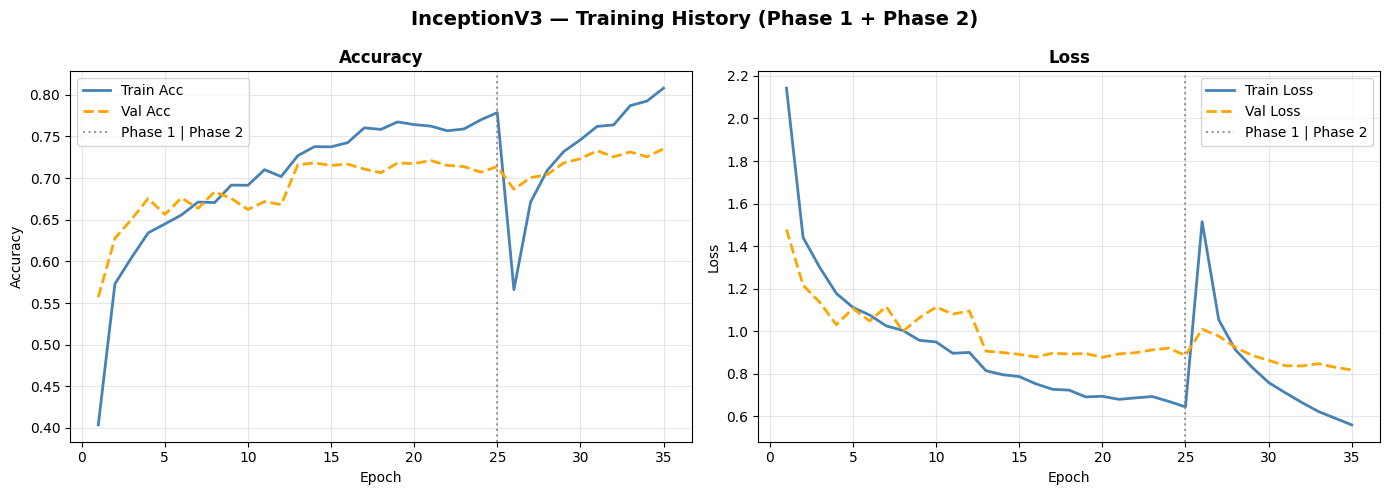

Saved training_plot.png


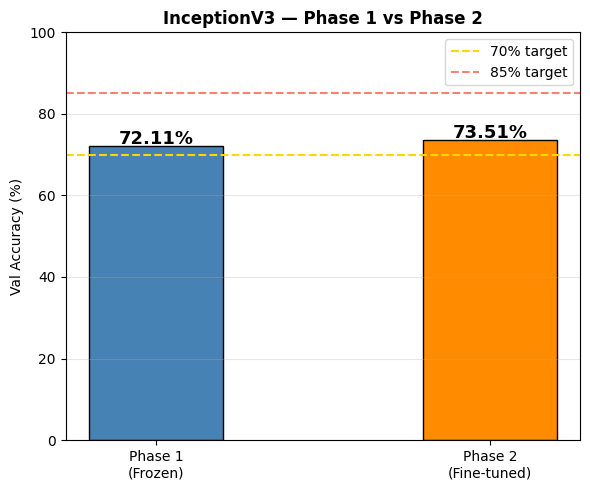

Saved phase_comparison_plot.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('InceptionV3 — Training History (Phase 1 + Phase 2)',
             fontsize=14, fontweight='bold')

total_ep = range(1, len(iv3_hist['accuracy']) + 1)

# Accuracy subplot
axes[0].plot(total_ep, iv3_hist['accuracy'],     color='steelblue', lw=2, label='Train Acc')
axes[0].plot(total_ep, iv3_hist['val_accuracy'], color='orange',    lw=2, linestyle='--', label='Val Acc')
axes[0].axvline(PHASE1_EPOCHS, color='gray', linestyle=':', alpha=0.8, label='Phase 1 | Phase 2')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Loss subplot
axes[1].plot(total_ep, iv3_hist['loss'],     color='steelblue', lw=2, label='Train Loss')
axes[1].plot(total_ep, iv3_hist['val_loss'], color='orange',    lw=2, linestyle='--', label='Val Loss')
axes[1].axvline(PHASE1_EPOCHS, color='gray', linestyle=':', alpha=0.8, label='Phase 1 | Phase 2')
axes[1].set_title('Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved training_plot.png")

# ── Phase comparison bar chart ──────────────────────────────────
p1_best = max(h_iv3_p1.history['val_accuracy'])
p2_best = max(h_iv3_p2.history['val_accuracy'])

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Phase 1\n(Frozen)', 'Phase 2\n(Fine-tuned)'],
              [p1_best * 100, p2_best * 100],
              color=['steelblue', 'darkorange'], width=0.4, edgecolor='black')
for bar, acc in zip(bars, [p1_best * 100, p2_best * 100]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=13)
ax.axhline(70, color='gold',   linestyle='--', label='70% target')
ax.axhline(85, color='salmon', linestyle='--', label='85% target')
ax.set_ylim(0, 100); ax.set_ylabel('Val Accuracy (%)')
ax.set_title('InceptionV3 — Phase 1 vs Phase 2', fontweight='bold')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'phase_comparison_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved phase_comparison_plot.png")

## Cell 18 — Classification Report

In [21]:
val_flow.reset()
y_pred = np.argmax(best_model.predict(val_flow, verbose=1), axis=1)
y_true = val_flow.classes
print(classification_report(y_true, y_pred, target_names=final_classes, zero_division=0))

43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 314ms/step
                         precision    recall  f1-score   support

 Japanese-style_pancake       0.92      0.86      0.89        28
             beef_curry       0.84      0.86      0.85        50
            beef_noodle       0.66      0.75      0.70        28
               bibimbap       0.80      0.87      0.83        23
chicken-'n'-egg_on_rice       0.74      0.56      0.64        25
           chicken_rice       0.67      0.80      0.73        20
             chip_butty       0.82      0.60      0.69        30
              croissant       0.92      1.00      0.96        24
              croquette       0.95      0.73      0.83        26
           eels_on_rice       0.96      0.96      0.96        26
           fried_noodle       0.68      0.56      0.61        27
             fried_rice       0.61      0.65      0.63        34
                 gratin       0.83      0.87      0.85        23
       grilled_eggplant       0.68      0.71   

## Cell 19 — Summary & Download Instructions

In [22]:
print("\n" + "="*55)
print(f"  TRAINING COMPLETE  |  InceptionV3  {iv3_acc*100:.2f}%")
print("="*55)
print(f"  Files saved in:  {SAVE_DIR}")
print()
print("  ► Saved files:")
print("      food_model.h5             ← trained model")
print("      class_names.json          ← class list")
print("      calorie_dict.json         ← calorie lookup")
print("      training_history.csv      ← epoch-by-epoch metrics")
print("      training_plot.png         ← accuracy/loss curves")
print("      phase_comparison_plot.png ← Phase 1 vs Phase 2 bar chart")
print()
print("  ► Download to your PC:")
print("      from google.colab import files")
print("      files.download('/content/drive/MyDrive/FoodAI/food_model.h5')")
print()
print("  ► Then run the Streamlit app locally:")
print("      pip install -r requirements.txt")
print("      streamlit run app.py")


  TRAINING COMPLETE  |  InceptionV3  73.51%
  Files saved in:  /content/drive/MyDrive/FoodAI

  ► Saved files:
      food_model.h5             ← trained model
      class_names.json          ← class list
      calorie_dict.json         ← calorie lookup
      training_history.csv      ← epoch-by-epoch metrics
      training_plot.png         ← accuracy/loss curves
      phase_comparison_plot.png ← Phase 1 vs Phase 2 bar chart

  ► Download to your PC:
      from google.colab import files
      files.download('/content/drive/MyDrive/FoodAI/food_model.h5')

  ► Then run the Streamlit app locally:
      pip install -r requirements.txt
      streamlit run app.py
